# Lab 5 – Transfer Learning avec PyTorch

## Objectifs
Dans ce laboratoire, vous allez :
1. Comprendre le concept du **Transfer Learning** (apprentissage par transfert)
2. Utiliser un modèle pré-entraîné (**ResNet-18**) sur ImageNet
3. Appliquer deux stratégies :
   - **Feature Extraction** : on gèle tous les poids sauf la dernière couche
   - **Fine-Tuning** : on ré-entraîne tout le réseau avec un faible learning rate
4. Comparer les résultats avec un modèle entraîné depuis zéro

---
### Qu'est-ce que le Transfer Learning ?

Le Transfer Learning consiste à **réutiliser les connaissances** apprises par un modèle entraîné sur une grande tâche (ex : ImageNet avec 1.2M images, 1000 classes) pour résoudre une **nouvelle tâche plus petite** (ex : distinguer des chats vs des chiens avec seulement quelques centaines d'images).

**Pourquoi ça marche ?**  
Les premières couches d'un CNN apprennent des features génériques (contours, textures, couleurs). Ces features sont utiles pour presque toutes les tâches de vision.

```
ImageNet (1.2M images) → ResNet pré-entraîné → Features génériques
                                                        ↓
Notre dataset (quelques centaines d'images)  → Adapter la dernière couche
```

## 1. Imports et configuration

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, models, transforms

import numpy as np
import matplotlib.pyplot as plt
import time
import os
import copy

# Vérifier si un GPU est disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositif utilisé : {device}")

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

Dispositif utilisé : cuda


## 2. Chargement et préparation des données

Nous utilisons le dataset **Hymenoptera** (fourmis vs abeilles) fourni par PyTorch.  
C'est un petit dataset : ~244 images d'entraînement et ~153 de validation.

### Data Augmentation
Pour l'entraînement, on applique des **augmentations aléatoires** pour améliorer la généralisation :
- `RandomResizedCrop` : recadrage aléatoire
- `RandomHorizontalFlip` : retournement horizontal aléatoire

Pour la validation, on applique uniquement un **redimensionnement et un recadrage central** (pas d'augmentation).

### Normalisation
Les valeurs `mean=[0.485, 0.456, 0.406]` et `std=[0.229, 0.224, 0.225]` correspondent aux **statistiques d'ImageNet**.  
Il faut les utiliser car notre modèle pré-entraîné a été entraîné avec ces valeurs.

In [2]:
import urllib.request
import zipfile

# Télécharger le dataset si nécessaire
if not os.path.exists('hymenoptera_data'):
    print("Téléchargement du dataset...")
    url = 'https://download.pytorch.org/tutorial/hymenoptera_data.zip'
    urllib.request.urlretrieve(url, 'hymenoptera_data.zip')
    with zipfile.ZipFile('hymenoptera_data.zip', 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Dataset téléchargé et extrait !")
else:
    print("Dataset déjà disponible.")

data_dir = 'hymenoptera_data'

Téléchargement du dataset...
Dataset téléchargé et extrait !


In [3]:
# -------------------------------------------------------
# Transformations : normalisation ImageNet + augmentation
# -------------------------------------------------------
data_transforms = {
    # Entraînement : augmentation aléatoire + normalisation
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),     # Recadrage aléatoire → 224×224
        transforms.RandomHorizontalFlip(),      # Flip horizontal aléatoire (p=0.5)
        transforms.ToTensor(),                  # Conversion PIL Image → Tensor [0,1]
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],         # Moyenne ImageNet
            std=[0.229, 0.224, 0.225]           # Écart-type ImageNet
        )
    ]),
    # Validation : redimensionnement + recadrage central seulement
    'val': transforms.Compose([
        transforms.Resize(256),                 # Redimensionner le petit côté à 256
        transforms.CenterCrop(224),             # Recadrage central 224×224
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ]),
}

# Chargement des datasets depuis les dossiers train/ et val/
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val']
}

# DataLoaders : batch de 32, shuffle pour l'entraînement
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=4)
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Classes : {class_names}")
print(f"Taille train : {dataset_sizes['train']} images")
print(f"Taille val   : {dataset_sizes['val']} images")

Classes : ['ants', 'bees']
Taille train : 244 images
Taille val   : 153 images


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 3. Visualisation des données

Avant de s'entraîner, toujours **visualiser quelques exemples** pour vérifier que les données sont correctement chargées et augmentées.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


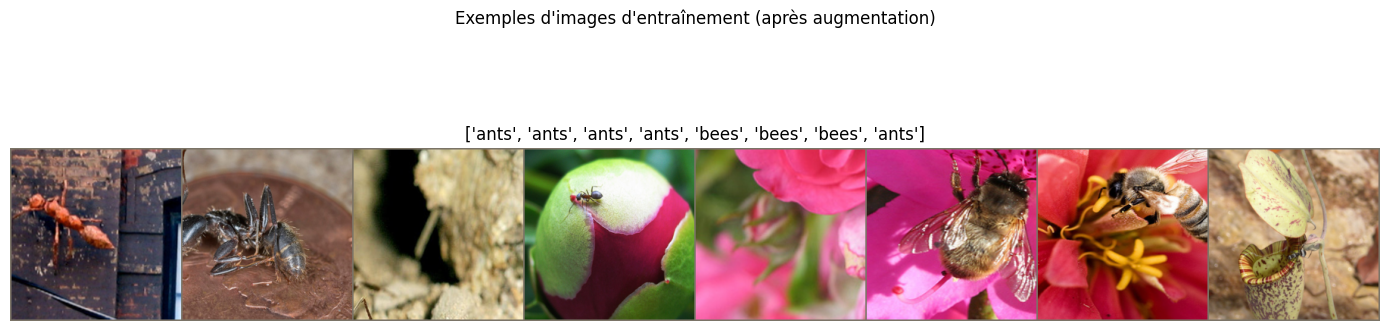

In [4]:
def imshow(inp, title=None):
    """
    Affiche un tenseur image après dénormalisation.

    Les images ont été normalisées avec les stats ImageNet.
    Pour les afficher, on doit inverser cette normalisation.
    """
    inp = inp.numpy().transpose((1, 2, 0))  # (C, H, W) → (H, W, C)

    # Dénormalisation
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)  # S'assurer que les valeurs restent dans [0,1]

    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')


# Afficher un batch d'images d'entraînement
inputs, classes = next(iter(dataloaders['train']))

# Créer une grille d'images
out = torchvision.utils.make_grid(inputs[:8])

plt.figure(figsize=(14, 4))
imshow(out, title=[class_names[c] for c in classes[:8]])
plt.suptitle("Exemples d'images d'entraînement (après augmentation)", y=1.02)
plt.tight_layout()
plt.show()

## 4. Fonction d'entraînement générique

Cette fonction gère **un cycle complet d'entraînement + validation** sur plusieurs epochs.  
Elle :
- Alterne entre mode `train` et `eval`
- Calcule la loss et l'accuracy à chaque epoch
- Sauvegarde le **meilleur modèle** selon la validation accuracy
- Retourne les courbes de loss et accuracy pour les visualiser

In [5]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    """
    Entraîne et valide le modèle.

    Args:
        model      : le réseau de neurones PyTorch
        criterion  : fonction de perte (ex: CrossEntropyLoss)
        optimizer  : algorithme d'optimisation (ex: SGD, Adam)
        scheduler  : planificateur du learning rate
        num_epochs : nombre d'époques d'entraînement

    Returns:
        model        : le meilleur modèle sauvegardé
        history      : dictionnaire avec les courbes loss/accuracy
    """
    since = time.time()

    # Sauvegarde du meilleur modèle
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Historique pour les courbes
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}  ', end='')
        print('-' * 40)

        # Chaque epoch a une phase d'entraînement ET de validation
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Mode entraînement : active Dropout, BatchNorm en mode train
            else:
                model.eval()   # Mode évaluation : désactive Dropout, BatchNorm utilise les stats globales

            running_loss = 0.0
            running_corrects = 0

            # Itérer sur les batches
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Remise à zéro des gradients à chaque batch
                optimizer.zero_grad()

                # Forward pass
                # torch.set_grad_enabled(False) en val pour économiser mémoire
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)          # Shape: (batch_size, num_classes)
                    _, preds = torch.max(outputs, 1) # Prédiction = classe avec le score max
                    loss = criterion(outputs, labels)

                    # Backward + optimisation seulement en entraînement
                    if phase == 'train':
                        loss.backward()   # Calcul des gradients
                        optimizer.step()  # Mise à jour des poids

                # Accumulation des métriques
                running_loss     += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Mise à jour du scheduler après chaque epoch d'entraînement
            if phase == 'train':
                scheduler.step()

            # Calcul des métriques moyennes sur l'epoch
            epoch_loss = running_loss     / dataset_sizes[phase]
            epoch_acc  = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase:5s} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')

            # Sauvegarder dans l'historique
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            # Garder le meilleur modèle selon la validation accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    # Résumé
    time_elapsed = time.time() - since
    print(f'\nEntraînement terminé en {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s')
    print(f'Meilleure accuracy validation : {best_acc:.4f}')

    # Charger les meilleurs poids
    model.load_state_dict(best_model_wts)
    return model, history

## 5. Stratégie 1 : Feature Extraction (Extraction de features)

### Principe
On **gèle tous les poids** du réseau pré-entraîné (en mettant `requires_grad = False`).  
Seule la **dernière couche fully-connected** (le classificateur) est remplacée et entraînée.

```
ResNet-18 pré-entraîné
├── Conv layers (GELÉES – pas de gradient)
├── BatchNorm (GELÉ)
├── ResBlocks (GELÉS)
└── FC (1000 classes) → REMPLACÉE par FC (2 classes) ← Seule partie entraînée
```

### Avantages
- Très rapide à entraîner (peu de paramètres)
- Fonctionne bien avec peu de données
- Faible risque d'overfitting

### Quand l'utiliser ?
- Quand votre dataset est **petit** (< 1000 images)
- Quand votre tâche est **similaire** à ImageNet

In [6]:
# ─── Chargement de ResNet-18 pré-entraîné sur ImageNet ───────────────────────
model_fe = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# ─── Gel de tous les paramètres ───────────────────────────────────────────────
# requires_grad=False : les gradients ne seront pas calculés pour ces paramètres
# → économie de mémoire et de calcul
for param in model_fe.parameters():
    param.requires_grad = False

# ─── Remplacement de la dernière couche ───────────────────────────────────────
# ResNet-18 a une couche fc finale : Linear(512, 1000) pour 1000 classes ImageNet
# On la remplace par Linear(512, 2) pour nos 2 classes (ants vs bees)
num_features = model_fe.fc.in_features  # 512 pour ResNet-18
model_fe.fc = nn.Linear(num_features, len(class_names))  # 2 classes

# La nouvelle fc est automatiquement entraînable (requires_grad=True par défaut)
model_fe = model_fe.to(device)

# Vérification : combien de paramètres sont entraînables ?
total_params     = sum(p.numel() for p in model_fe.parameters())
trainable_params = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
print(f"Paramètres totaux     : {total_params:,}")
print(f"Paramètres entraînables : {trainable_params:,}")
print(f"Proportion entraînée  : {100*trainable_params/total_params:.2f}%")

# ─── Critère de perte ─────────────────────────────────────────────────────────
# CrossEntropyLoss = SoftMax + NLLLoss, adapté pour la classification multi-classes
criterion = nn.CrossEntropyLoss()

# ─── Optimiseur ───────────────────────────────────────────────────────────────
# On passe UNIQUEMENT les paramètres de la fc (les seuls avec requires_grad=True)
optimizer_fe = optim.SGD(
    filter(lambda p: p.requires_grad, model_fe.parameters()),
    lr=0.001,
    momentum=0.9
)

# ─── Scheduler : StepLR ───────────────────────────────────────────────────────
# Divise le learning rate par 10 (gamma=0.1) tous les 7 epochs
# Epoch 1-7  : lr = 0.001
# Epoch 8-14 : lr = 0.0001
# etc.
scheduler_fe = lr_scheduler.StepLR(optimizer_fe, step_size=7, gamma=0.1)

print("\nArchitecture de la dernière couche :")
print(model_fe.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 152MB/s]


Paramètres totaux     : 11,177,538
Paramètres entraînables : 1,026
Proportion entraînée  : 0.01%

Architecture de la dernière couche :
Linear(in_features=512, out_features=2, bias=True)


In [7]:
# Entraînement – Feature Extraction
print("=" * 50)
print("STRATÉGIE 1 : FEATURE EXTRACTION")
print("=" * 50)

model_fe, history_fe = train_model(
    model_fe, criterion, optimizer_fe, scheduler_fe,
    num_epochs=25
)

STRATÉGIE 1 : FEATURE EXTRACTION
Epoch 1/25  ----------------------------------------
train | Loss: 0.7258 | Acc: 0.5000
val   | Loss: 0.6435 | Acc: 0.6405
Epoch 2/25  ----------------------------------------
train | Loss: 0.5596 | Acc: 0.7500
val   | Loss: 0.4467 | Acc: 0.8431
Epoch 3/25  ----------------------------------------
train | Loss: 0.4089 | Acc: 0.8402
val   | Loss: 0.3251 | Acc: 0.9216
Epoch 4/25  ----------------------------------------
train | Loss: 0.3334 | Acc: 0.8852
val   | Loss: 0.2680 | Acc: 0.9346
Epoch 5/25  ----------------------------------------
train | Loss: 0.3035 | Acc: 0.8975
val   | Loss: 0.2413 | Acc: 0.9542
Epoch 6/25  ----------------------------------------
train | Loss: 0.2451 | Acc: 0.9344
val   | Loss: 0.2221 | Acc: 0.9542
Epoch 7/25  ----------------------------------------
train | Loss: 0.2563 | Acc: 0.8975
val   | Loss: 0.2260 | Acc: 0.9412
Epoch 8/25  ----------------------------------------
train | Loss: 0.2375 | Acc: 0.9057
val   | Loss: 0.22

## 6. Stratégie 2 : Fine-Tuning

### Principe
On charge le même modèle pré-entraîné, mais cette fois on **entraîne TOUS les paramètres** (sans geler).  
Cependant, on utilise un **learning rate très faible** pour ne pas "oublier" trop vite les features ImageNet.

```
ResNet-18 pré-entraîné
├── Conv layers (ENTRAÎNÉS avec lr petit)
├── BatchNorm (ENTRAÎNÉ)
├── ResBlocks (ENTRAÎNÉS)
└── FC (2 classes) ← Entraîné avec lr normal
```

### Avantages
- Performance généralement **supérieure** à la feature extraction
- S'adapte mieux si la tâche est **différente** d'ImageNet

### Risques
- **Catastrophic forgetting** : si lr trop grand, le modèle oublie les features ImageNet
- Risque d'**overfitting** si dataset trop petit

### Bonne pratique : lr différentiel
On peut donner un **lr plus petit aux premières couches** et un **lr plus grand à la dernière couche** :

In [8]:
# ─── Chargement d'un nouveau ResNet-18 pré-entraîné ──────────────────────────
model_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# ─── Remplacement de la dernière couche (comme avant) ─────────────────────────
num_features = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_features, len(class_names))
model_ft = model_ft.to(device)

# ─── Cette fois, TOUS les paramètres sont entraînables ───────────────────────
# (pas besoin de boucle pour geler : requires_grad=True est la valeur par défaut)
total_params     = sum(p.numel() for p in model_ft.parameters())
trainable_params = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

# ─── Optimiseur avec learning rates différentiels ─────────────────────────────
# Les couches du backbone (tout sauf fc) : lr = 0.0001 (petit)
# La couche fc (classificateur)          : lr = 0.001  (normal)
# Cela permet de ré-ajuster finement les features sans les détruire
backbone_params = [p for name, p in model_ft.named_parameters() if 'fc' not in name]
head_params     = model_ft.fc.parameters()

optimizer_ft = optim.SGD(
    [
        {'params': backbone_params, 'lr': 0.0001},  # Backbone : lr ×10 plus petit
        {'params': head_params,     'lr': 0.001 },  # Tête     : lr normal
    ],
    momentum=0.9
)

scheduler_ft = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

print("\nLearning rates différentiels configurés :")
for i, pg in enumerate(optimizer_ft.param_groups):
    print(f"  Groupe {i} → lr = {pg['lr']}")

Paramètres entraînables : 11,177,538 / 11,177,538 (100.0%)

Learning rates différentiels configurés :
  Groupe 0 → lr = 0.0001
  Groupe 1 → lr = 0.001


In [9]:
# Entraînement – Fine-Tuning
print("=" * 50)
print("STRATÉGIE 2 : FINE-TUNING")
print("=" * 50)

model_ft, history_ft = train_model(
    model_ft, criterion, optimizer_ft, scheduler_ft,
    num_epochs=25
)

STRATÉGIE 2 : FINE-TUNING
Epoch 1/25  ----------------------------------------
train | Loss: 0.7145 | Acc: 0.5410
val   | Loss: 0.6711 | Acc: 0.6340
Epoch 2/25  ----------------------------------------
train | Loss: 0.5390 | Acc: 0.7377
val   | Loss: 0.4178 | Acc: 0.8693
Epoch 3/25  ----------------------------------------
train | Loss: 0.4061 | Acc: 0.8730
val   | Loss: 0.3283 | Acc: 0.8954
Epoch 4/25  ----------------------------------------
train | Loss: 0.3215 | Acc: 0.9057
val   | Loss: 0.2569 | Acc: 0.9281
Epoch 5/25  ----------------------------------------
train | Loss: 0.2798 | Acc: 0.9016
val   | Loss: 0.2426 | Acc: 0.9216
Epoch 6/25  ----------------------------------------
train | Loss: 0.2403 | Acc: 0.9262
val   | Loss: 0.2170 | Acc: 0.9281
Epoch 7/25  ----------------------------------------
train | Loss: 0.1850 | Acc: 0.9508
val   | Loss: 0.2096 | Acc: 0.9216
Epoch 8/25  ----------------------------------------
train | Loss: 0.1884 | Acc: 0.9508
val   | Loss: 0.2094 | Ac

## 7. Comparaison : Modèle entraîné depuis zéro (Baseline)

Pour illustrer l'avantage du Transfer Learning, on entraîne le même réseau **sans pré-entraînement** (poids aléatoires).

In [10]:
# ─── ResNet-18 SANS pré-entraînement (poids initialisés aléatoirement) ────────
model_scratch = models.resnet18(weights=None)  # weights=None = pas de pré-entraînement
model_scratch.fc = nn.Linear(model_scratch.fc.in_features, len(class_names))
model_scratch = model_scratch.to(device)

optimizer_scratch = optim.SGD(model_scratch.parameters(), lr=0.01, momentum=0.9)
scheduler_scratch = lr_scheduler.StepLR(optimizer_scratch, step_size=7, gamma=0.1)

print("=" * 50)
print("BASELINE : ENTRAÎNÉ DEPUIS ZÉRO")
print("=" * 50)

model_scratch, history_scratch = train_model(
    model_scratch, criterion, optimizer_scratch, scheduler_scratch,
    num_epochs=25
)

BASELINE : ENTRAÎNÉ DEPUIS ZÉRO
Epoch 1/25  ----------------------------------------
train | Loss: 0.8896 | Acc: 0.5041
val   | Loss: 0.9300 | Acc: 0.5490
Epoch 2/25  ----------------------------------------
train | Loss: 0.8876 | Acc: 0.6066
val   | Loss: 2.6534 | Acc: 0.5621
Epoch 3/25  ----------------------------------------
train | Loss: 0.8234 | Acc: 0.6844
val   | Loss: 2.7275 | Acc: 0.4706
Epoch 4/25  ----------------------------------------
train | Loss: 0.7411 | Acc: 0.5984
val   | Loss: 4.5286 | Acc: 0.5490
Epoch 5/25  ----------------------------------------
train | Loss: 0.9679 | Acc: 0.6311
val   | Loss: 1.7728 | Acc: 0.6013
Epoch 6/25  ----------------------------------------
train | Loss: 0.7980 | Acc: 0.6680
val   | Loss: 1.4437 | Acc: 0.6078
Epoch 7/25  ----------------------------------------
train | Loss: 0.7661 | Acc: 0.5984
val   | Loss: 1.3496 | Acc: 0.6863
Epoch 8/25  ----------------------------------------
train | Loss: 0.6719 | Acc: 0.6639
val   | Loss: 0.591

## 8. Visualisation des courbes d'apprentissage

On compare les **courbes de loss et d'accuracy** pour les 3 stratégies.

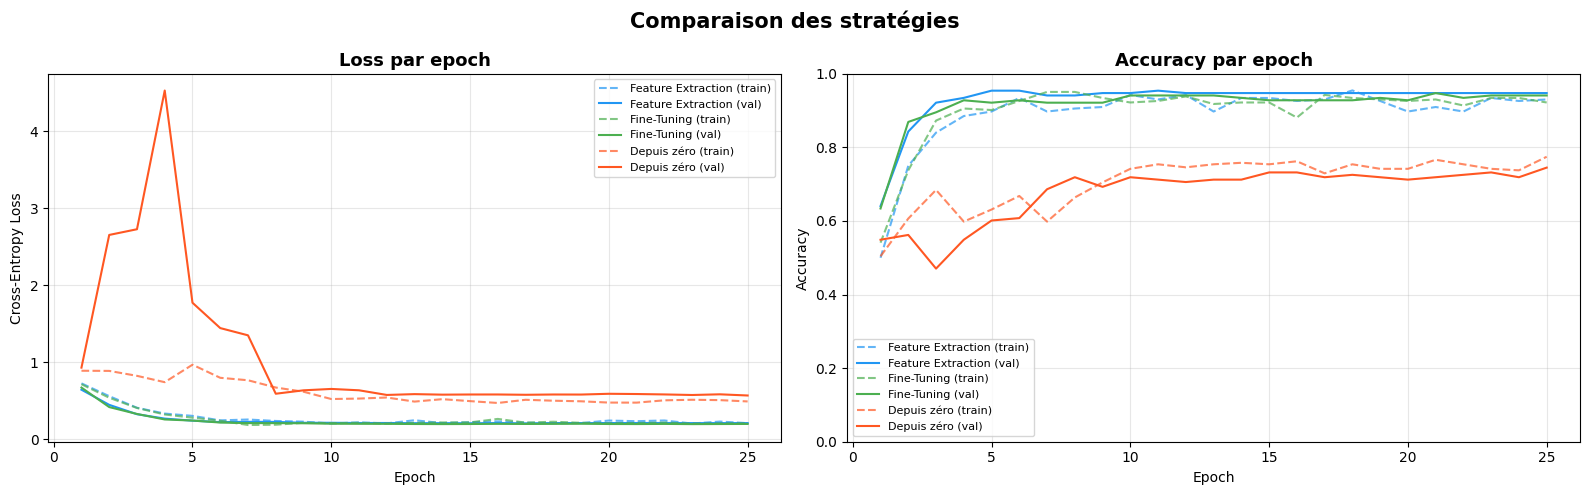

In [11]:
def plot_training_curves(histories, labels, title="Comparaison des stratégies"):
    """
    Affiche les courbes loss et accuracy pour plusieurs modèles.

    Args:
        histories : liste de dictionnaires d'historiques
        labels    : liste de noms pour la légende
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors = ['#2196F3', '#4CAF50', '#FF5722']

    for hist, label, color in zip(histories, labels, colors):
        epochs = range(1, len(hist['train_loss']) + 1)

        # --- Courbe de Loss ---
        axes[0].plot(epochs, hist['train_loss'], '--', color=color, alpha=0.7, label=f'{label} (train)')
        axes[0].plot(epochs, hist['val_loss'],   '-',  color=color,            label=f'{label} (val)')

    axes[0].set_title('Loss par epoch', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    for hist, label, color in zip(histories, labels, colors):
        epochs = range(1, len(hist['train_acc']) + 1)

        # --- Courbe d'Accuracy ---
        axes[1].plot(epochs, hist['train_acc'], '--', color=color, alpha=0.7, label=f'{label} (train)')
        axes[1].plot(epochs, hist['val_acc'],   '-',  color=color,            label=f'{label} (val)')

    axes[1].set_title('Accuracy par epoch', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim([0, 1])
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_training_curves(
    [history_fe, history_ft, history_scratch],
    ['Feature Extraction', 'Fine-Tuning', 'Depuis zéro']
)

## 9. Évaluation finale et tableau comparatif

In [12]:
def evaluate_model(model, dataloader):
    """
    Évalue le modèle sur un dataloader et retourne l'accuracy.
    """
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():  # Pas de calcul de gradient en évaluation
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total


# Accuracy finale sur le set de validation
acc_fe      = evaluate_model(model_fe,      dataloaders['val'])
acc_ft      = evaluate_model(model_ft,      dataloaders['val'])
acc_scratch = evaluate_model(model_scratch, dataloaders['val'])

# Tableau récapitulatif
print("\n" + "═" * 60)
print("      TABLEAU COMPARATIF – Accuracy sur la validation")
print("═" * 60)
print(f"  {'Stratégie':<30} {'Val Accuracy':>15}")
print("-" * 60)
print(f"  {'Feature Extraction':<30} {acc_fe*100:>14.2f}%")
print(f"  {'Fine-Tuning':<30} {acc_ft*100:>14.2f}%")
print(f"  {'Depuis zéro (baseline)':<30} {acc_scratch*100:>14.2f}%")
print("═" * 60)
print(f"\nGain Feature Extraction vs Baseline : +{(acc_fe - acc_scratch)*100:.2f}%")
print(f"Gain Fine-Tuning vs Baseline         : +{(acc_ft - acc_scratch)*100:.2f}%")


════════════════════════════════════════════════════════════
      TABLEAU COMPARATIF – Accuracy sur la validation
════════════════════════════════════════════════════════════
  Stratégie                         Val Accuracy
------------------------------------------------------------
  Feature Extraction                      95.42%
  Fine-Tuning                             94.77%
  Depuis zéro (baseline)                  74.51%
════════════════════════════════════════════════════════════

Gain Feature Extraction vs Baseline : +20.92%
Gain Fine-Tuning vs Baseline         : +20.26%


## 10. Visualisation des prédictions

On affiche quelques images avec les prédictions du meilleur modèle (Fine-Tuning) pour avoir une intuition visuelle des résultats.

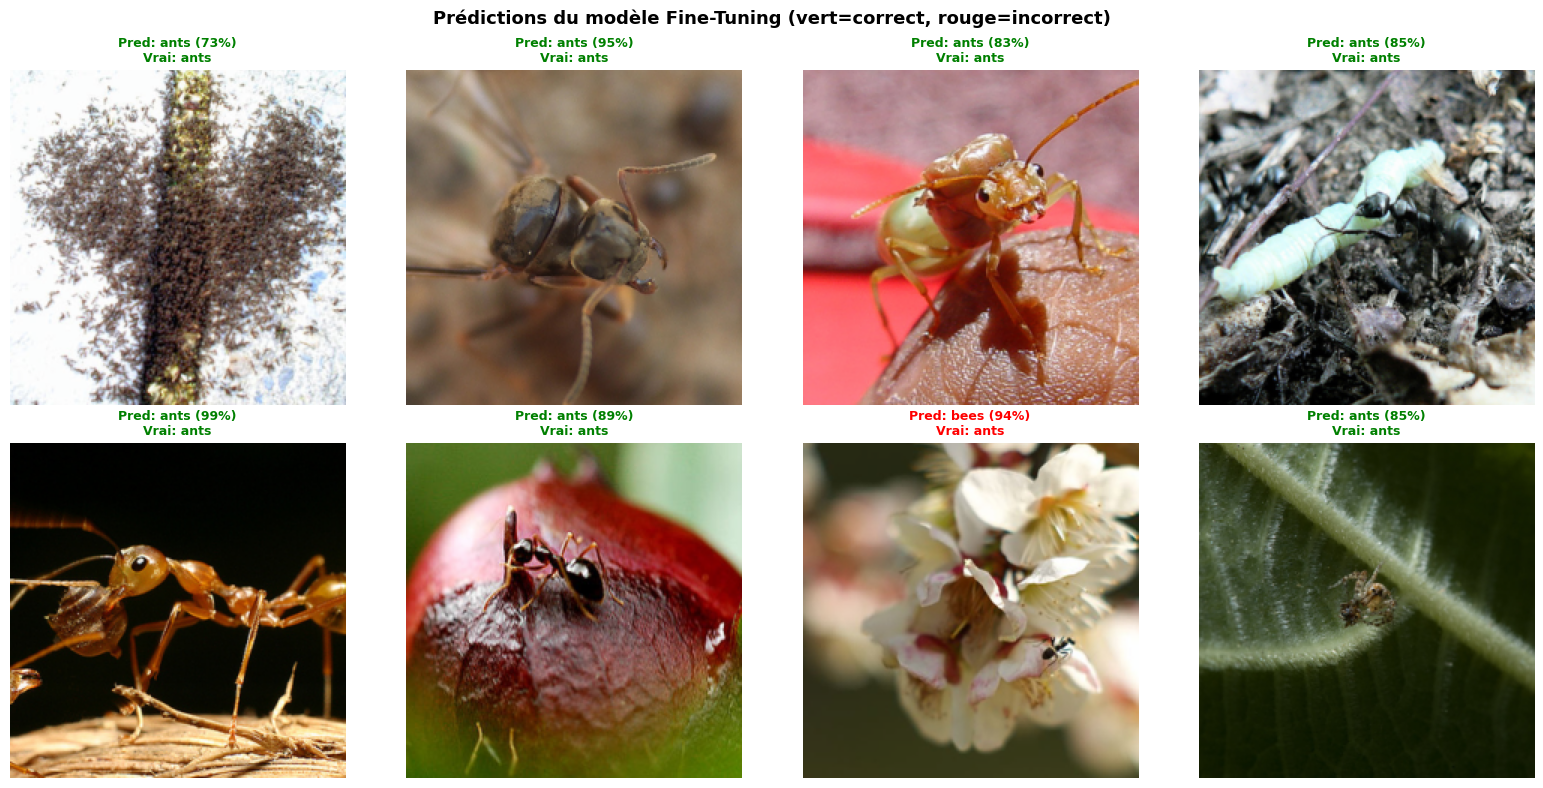

In [13]:
def visualize_predictions(model, num_images=8):
    """
    Affiche num_images exemples avec les prédictions et les vraies étiquettes.
    Vert = bonne prédiction, Rouge = mauvaise prédiction.
    """
    model.eval()
    images_so_far = 0

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # Probabilités via Softmax
            probs = torch.nn.functional.softmax(outputs, dim=1)

            for j in range(inputs.size(0)):
                if images_so_far >= num_images:
                    break

                ax = axes[images_so_far]

                # Dénormaliser l'image
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                img = np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406])
                img = np.clip(img, 0, 1)

                ax.imshow(img)
                ax.axis('off')

                # Couleur du titre : vert si correct, rouge si incorrect
                pred_class = class_names[preds[j]]
                true_class = class_names[labels[j]]
                conf = probs[j][preds[j]].item()

                color = 'green' if preds[j] == labels[j] else 'red'
                ax.set_title(
                    f"Pred: {pred_class} ({conf:.0%})\nVrai: {true_class}",
                    color=color, fontsize=9, fontweight='bold'
                )

                images_so_far += 1

            if images_so_far >= num_images:
                break

    plt.suptitle("Prédictions du modèle Fine-Tuning (vert=correct, rouge=incorrect)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


visualize_predictions(model_ft)

## 11. Analyse de l'architecture ResNet-18

Pour mieux comprendre ce qu'on modifie, voici un aperçu de l'architecture.

In [14]:
# Afficher l'architecture complète de ResNet-18
print("Architecture ResNet-18 :")
print("=" * 60)
for name, module in model_ft.named_children():
    num_params = sum(p.numel() for p in module.parameters())
    print(f"  {name:15s} → {type(module).__name__:20s} | {num_params:>8,} paramètres")

print("\n" + "=" * 60)
print("Résumé :")
total = sum(p.numel() for p in model_ft.parameters())
print(f"  Total paramètres : {total:,}")
print(f"  Taille approximative : ~{total*4/1024/1024:.1f} MB (float32)")

Architecture ResNet-18 :
  conv1           → Conv2d               |    9,408 paramètres
  bn1             → BatchNorm2d          |      128 paramètres
  relu            → ReLU                 |        0 paramètres
  maxpool         → MaxPool2d            |        0 paramètres
  layer1          → Sequential           |  147,968 paramètres
  layer2          → Sequential           |  525,568 paramètres
  layer3          → Sequential           | 2,099,712 paramètres
  layer4          → Sequential           | 8,393,728 paramètres
  avgpool         → AdaptiveAvgPool2d    |        0 paramètres
  fc              → Linear               |    1,026 paramètres

Résumé :
  Total paramètres : 11,177,538
  Taille approximative : ~42.6 MB (float32)


## 12. Questions de réflexion

### Q1 – Nombre de paramètres
Combien de paramètres sont entraînés dans chaque stratégie ?
Pourquoi la Feature Extraction est-elle plus rapide ?

**Réponse :**  
- Feature Extraction : seulement les paramètres de la dernière couche `fc` → **512×2 + 2 = 1026 paramètres**
- Fine-Tuning : tous les paramètres → **~11.2M paramètres**  
→ La Feature Extraction est ~10 000× plus rapide par epoch car très peu de gradients à calculer.

---

### Q2 – Quand utiliser quelle stratégie ?

| Situation | Stratégie recommandée |
|-----------|----------------------|
| Dataset petit + tâche similaire à ImageNet | Feature Extraction |
| Dataset moyen + tâche similaire | Fine-Tuning (lr petit) |
| Dataset grand + tâche différente | Fine-Tuning complet ou ré-entraîner |
| Dataset très petit + tâche très différente | Feature Extraction (risque overfitting) |

---

### Q3 – Qu'est-ce que le Catastrophic Forgetting ?

Si on utilise un **learning rate trop grand** en Fine-Tuning, les poids du réseau changent trop rapidement et le modèle "oublie" les features génériques apprises sur ImageNet.  
→ Solution : utiliser un **lr faible** (ex: 10× ou 100× plus petit que pour un entraînement from scratch).

---

### Q4 – Que fait le `lr_scheduler.StepLR` ?

Il **diminue le learning rate** au fil des epochs selon un calendrier fixe :  
`lr_new = lr_old × gamma` tous les `step_size` epochs.  
Avec `step_size=7` et `gamma=0.1` : le lr est divisé par 10 à la 8ème epoch, puis encore à la 15ème.

Cela permet une **convergence plus fine** en fin d'entraînement.

## 13. Sauvegarde des modèles

On sauvegarde les modèles entraînés pour une utilisation future.

In [15]:
# Sauvegarder les state_dict (recommandé par PyTorch)
# state_dict = dictionnaire {nom_couche: tenseur_poids}
torch.save(model_fe.state_dict(),      'model_feature_extraction.pth')
torch.save(model_ft.state_dict(),      'model_fine_tuning.pth')
torch.save(model_scratch.state_dict(), 'model_from_scratch.pth')

print("Modèles sauvegardés :")
print("  model_feature_extraction.pth")
print("  model_fine_tuning.pth")
print("  model_from_scratch.pth")

# Pour recharger un modèle plus tard :
# model = models.resnet18()
# model.fc = nn.Linear(512, 2)
# model.load_state_dict(torch.load('model_fine_tuning.pth'))
# model.eval()

Modèles sauvegardés :
  model_feature_extraction.pth
  model_fine_tuning.pth
  model_from_scratch.pth


## Récapitulatif – Ce qu'il faut retenir

```
┌─────────────────────────────────────────────────────────────────┐
│                    TRANSFER LEARNING                            │
├───────────────────────┬─────────────────────────────────────────┤
│ Feature Extraction    │ Fine-Tuning                             │
├───────────────────────┼─────────────────────────────────────────┤
│ Gèle le backbone      │ Entraîne tout le réseau                 │
│ Entraîne seul. la fc  │ lr petit pour le backbone               │
│ Rapide, peu de params │ Plus lent, + de params                  │
│ Bon si dataset petit  │ Meilleur si assez de données             │
│ ~1K paramètres        │ ~11M paramètres                         │
└───────────────────────┴─────────────────────────────────────────┘

Les deux >> Entraîné depuis zéro  (sur petits datasets)
```

**Règle générale :**  
→ Commencez toujours par la Feature Extraction.  
→ Si les résultats sont insuffisants, passez au Fine-Tuning.